<a href="https://colab.research.google.com/github/irem-irmak-tokdemir/tech-istanbul-data-science-bootcamp/blob/main/06_dogrusal_regresyon_ve_yapay_sinir_agi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
veri_yolu="/content/drive/My Drive/Tech İstanbul/enerji_tuketimi.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


# doğrusal regrasyon

In [ ]:
from numpy.random.mtrand import random
veri=pd.read_csv(veri_yolu)
x=veri[["sicaklik"]]
y = veri[["enerji"]]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)



In [ ]:
model= LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_predict=model.predict(x_test)
mse=mean_squared_error(y_test,y_predict)
r2=r2_score(y_test,y_predict)
# print("Doğrusal regrasyonun hata skoru(mse):",mse, "\n Doğrusal Regresyonun R2 si ise:",r2)


# Yapay sinir ağları

In [ ]:
xölçek=StandardScaler()
ölçek=StandardScaler()
x_ölçekli=xölçek.fit_transform(x_train)
x_ölçekli_test=xölçek.transform(x_test)
y_ölçekli=ölçek.fit_transform(y_train)
y_ölçekli_test=ölçek.transform(y_test)

In [ ]:
model2=MLPRegressor(max_iter=1000,random_state=42)
model2.fit(x_ölçekli,y_ölçekli)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPRegressor(max_iter=1000, random_state=42)

In [ ]:
y_yapay_predict=model2.predict(x_ölçekli_test)
y_yapay_predict_gercek = (
    y_yapay_predict * ölçek.scale_[0]
    + ölçek.mean_[0]
)
x_tum_scaled = xölçek.transform(x)

y_yapay_tum = model2.predict(x_tum_scaled)

y_yapay_tum_gercek = (
    y_yapay_tum * ölçek.scale_[0]
    + ölçek.mean_[0]
)

mse2 = mean_squared_error(
    y_test,
    y_yapay_predict_gercek
)

r2y = r2_score(
    y_test,
    y_yapay_predict_gercek
)

print(mse2 ,r2y)


198.70922515844907 0.9448176914325657


# tablo

                Model          MSE        R2
0  Doğrusal Regresyon  1171.400394  0.674698
1  Yapay Sinir Ağları   198.709225  0.944818


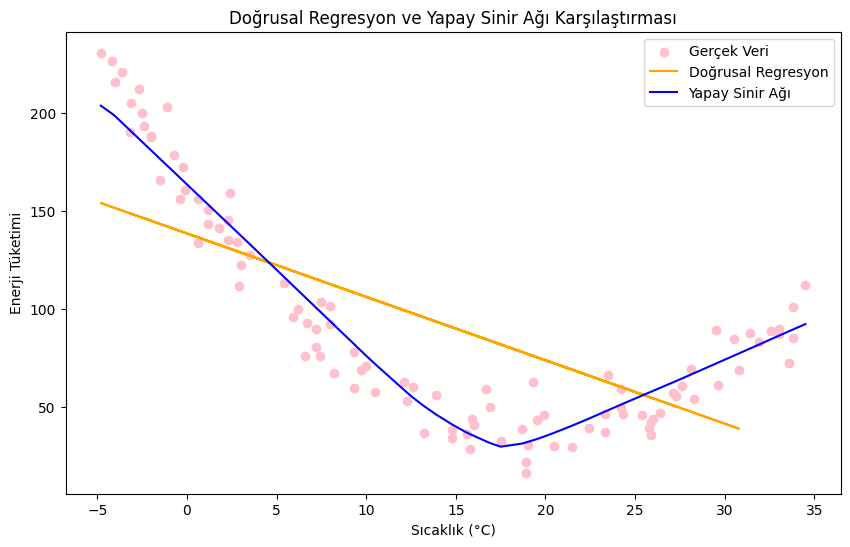

In [ ]:
isimler = [
    "Doğrusal Regresyon",
    "Yapay Sinir Ağları"

]
mse = [
    mse,
    mse2
]

r2 = [
    r2,
    r2y
]
tablo = pd.DataFrame({
    "Model": isimler,
    "MSE": mse,
    "R2": r2
})
print(tablo)




plt.figure(figsize=(10,6))
plt.scatter(x,y,color="pink",label="Gerçek Veri")
plt.plot(x_test,y_predict,color="orange",label="Doğrusal Regresyon")
plt.plot(x,y_yapay_tum_gercek,color="blue",label="Yapay Sinir Ağı")

plt.xlabel("Sıcaklık (°C)")
plt.ylabel("Enerji Tüketimi")
plt.title("Doğrusal Regresyon ve Yapay Sinir Ağı Karşılaştırması")
plt.legend()
plt.show()
